## Defense CAT: Retrain with adversarial from Surrogate MLP

Pipeline: Train surrogate MLP → Generate adv on TRAIN data → Retrain CAT → Evaluate on surrogate adv TEST

### 1. Import

In [3]:
import os, sys, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset
from catboost import CatBoostClassifier
from art.estimators.classification import PyTorchClassifier, CatBoostARTClassifier

from art_generator import (
    FGSMAttackGenerator, PGDAttackGenerator, CWAttackGenerator,
    DeepFoolAttackGenerator, MIMAttackGenerator,
)
from utils.masking import get_mutate_indices
from utils.paths import load_attack_config

import warnings
warnings.filterwarnings('ignore')

/Users/trungnguye2n.dev/foami-plus/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Surrogate MLP

In [3]:
class _SurrogateMLP(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, n_classes),
        )
    def forward(self, x):
        return self.net(x)

class _ScaledMLP(nn.Module):
    def __init__(self, mlp, mean, scale):
        super().__init__()
        self.mlp = mlp
        self.register_buffer('mean_', torch.tensor(mean, dtype=torch.float32))
        self.register_buffer('scale_', torch.tensor(scale, dtype=torch.float32))
    def forward(self, x):
        return self.mlp((x.float() - self.mean_) / self.scale_)

### 3. Load data

In [4]:
DEVICE = 'cpu'

# Test data
df_test = pd.read_csv('../../datasets/test_shap_66.csv')
X_test = df_test.drop(columns=['Label']).values.astype(np.float32)
y_test = df_test['Label'].values.astype(int)
feature_names = df_test.columns[:-1].tolist()

# Training data
df_train = pd.read_csv('../../datasets/augment/train_tvae_9600.csv')
X_train = df_train.drop(columns=['Label']).values.astype(np.float32)
y_train = df_train['Label'].values.astype(int)

input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))

input_metadata = {'feature_names': feature_names, 'label_column': 'Label'}
mutate_indices = get_mutate_indices(df_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}, Classes: {num_classes}')

Train: (9600, 66), Test: (2028, 66), Classes: 12


### 4. Train surrogate MLP

In [5]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)

train_ds = TensorDataset(torch.from_numpy(X_train_sc), torch.from_numpy(y_train).long())
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)

torch.manual_seed(42)
surrogate = _SurrogateMLP(input_dim, num_classes).to(DEVICE)
optimizer = torch.optim.AdamW(surrogate.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
criterion = nn.CrossEntropyLoss()

for epoch in range(100):
    surrogate.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(surrogate(xb), yb)
        loss.backward()
        optimizer.step()
    scheduler.step()
    if (epoch + 1) % 20 == 0:
        surrogate.eval()
        with torch.no_grad():
            preds = torch.argmax(surrogate(torch.from_numpy(X_test_sc).to(DEVICE)), dim=1).cpu().numpy()
        print(f'Epoch {epoch+1}: test acc = {accuracy_score(y_test, preds)*100:.2f}%')

surrogate.eval()
print('Surrogate training done.')

Epoch 20: test acc = 67.80%
Epoch 40: test acc = 68.15%
Epoch 60: test acc = 69.38%
Epoch 80: test acc = 69.63%
Epoch 100: test acc = 69.63%
Surrogate training done.


### 5. ART classifier + generate adv on TRAIN data

In [6]:
scaled_surrogate = _ScaledMLP(surrogate, scaler.mean_, scaler.scale_).to(DEVICE)
scaled_surrogate.eval()

surrogate_clf = PyTorchClassifier(
    model=scaled_surrogate,
    loss=nn.CrossEntropyLoss(),
    input_shape=(input_dim,),
    nb_classes=num_classes,
    clip_values=(float(X_train.min()), float(X_train.max())),
    device_type=DEVICE,
)

preds = np.argmax(surrogate_clf.predict(X_test), axis=1)
print(f'Surrogate acc on test: {accuracy_score(y_test, preds)*100:.2f}%')

Surrogate acc on test: 69.63%


In [7]:
ADV_TRAIN_DIR = '../../adv_samples/adv_training/surrogate'
os.makedirs(ADV_TRAIN_DIR, exist_ok=True)

ATTACK_MAP = {
    'fgsm':     FGSMAttackGenerator,
    'pgd':      PGDAttackGenerator,
    'deepfool': DeepFoolAttackGenerator,
    'cw':       CWAttackGenerator,
    'mim':      MIMAttackGenerator,
}

ATTACK_NAMES = ['fgsm', 'pgd', 'deepfool', 'cw', 'mim']

for atk_name in ATTACK_NAMES:
    cfg = load_attack_config(atk_name)
    gen = ATTACK_MAP[atk_name](surrogate_clf, generator_params=cfg)

    print(f'\n=== Generating {atk_name.upper()} on TRAIN data ===')
    start = time.time()
    df_adv = gen.generate(X_train, y_train, input_metadata, mutate_indices=mutate_indices)
    print(f'Runtime: {time.time() - start:.2f}s')

    path = os.path.join(ADV_TRAIN_DIR, f'surrogate_{atk_name}_train_adv.csv')
    df_adv.to_csv(path, index=False)
    print(f'Saved: {path}')

print('\nDone generating surrogate adv training data.')


=== Generating FGSM on TRAIN data ===
Runtime: 0.19s
Saved: ../../adv_samples/adv_training/surrogate/surrogate_fgsm_train_adv.csv

=== Generating PGD on TRAIN data ===


Runtime: 19.35s
Saved: ../../adv_samples/adv_training/surrogate/surrogate_pgd_train_adv.csv

=== Generating DEEPFOOL on TRAIN data ===


DeepFool: 100%|██████████| 150/150 [00:02<00:00, 63.42it/s]


Runtime: 2.41s
Saved: ../../adv_samples/adv_training/surrogate/surrogate_deepfool_train_adv.csv

=== Generating CW on TRAIN data ===
Runtime: 8.82s
Saved: ../../adv_samples/adv_training/surrogate/surrogate_cw_train_adv.csv

=== Generating MIM on TRAIN data ===


Runtime: 10.09s
Saved: ../../adv_samples/adv_training/surrogate/surrogate_mim_train_adv.csv

Done generating surrogate adv training data.


### 6. Load surrogate adv + retrain CAT

In [63]:
ADV_TRAIN_DIR = '../../adv_samples/adv_training/surrogate'

# Trọng số theo post-AT ASR: attack ASR còn cao → cần nhiều sample hơn
WB_ATTACKS = [
    ('fgsm',     4.0),   # ASR 24.2% → cần thêm
    ('pgd',      3.0),   # ASR 19.5% → khá tốt rồi
    ('deepfool', 5.0),   # ASR 23.5% → cần nhiều nhất
    ('cw',       2.0),   # ASR 16.3% → đã tốt, giảm bớt
    ('mim',      3.0),   # ASR 18.7% → trung bình
]

CLEAN_ADV_RATIO = 7# giữ 0.5 để balance clean/adv
n_clean = len(X_train)
n_adv_budget = int(n_clean * CLEAN_ADV_RATIO)
total_weight = sum(w for _, w in WB_ATTACKS)

rng = np.random.RandomState(42)
parts_X, parts_y = [], []

print(f'Budget: {n_adv_budget} adv samples (clean={n_clean}, ratio={CLEAN_ADV_RATIO})\n')

for atk_name, weight in WB_ATTACKS:
    path = os.path.join(ADV_TRAIN_DIR, f'surrogate_{atk_name}_train_adv.csv')
    if not os.path.exists(path):
        print(f'  [SKIP] {path}')
        continue
    df = pd.read_csv(path)
    X_atk = df.drop(columns=['Label']).values.astype(np.float32)
    y_atk = df['Label'].values.astype(int)

    n_sample = int(n_adv_budget * weight / total_weight)
    n_sample = min(n_sample, len(X_atk))
    idx = rng.choice(len(X_atk), size=n_sample, replace=False)
    parts_X.append(X_atk[idx])
    parts_y.append(y_atk[idx])
    print(f'  {atk_name:>10s}: {len(X_atk)} -> {n_sample}  (weight={weight})')

adv_X = np.concatenate(parts_X)
adv_y = np.concatenate(parts_y)

X_train_at = np.concatenate([X_train, adv_X])
y_train_at = np.concatenate([y_train, adv_y])

# Dedup
df_tmp = pd.DataFrame(X_train_at)
df_tmp['_lbl'] = y_train_at
n_before = len(df_tmp)
df_tmp = df_tmp.drop_duplicates()
X_train_at = df_tmp.drop(columns=['_lbl']).values.astype(np.float32)
y_train_at = df_tmp['_lbl'].values.astype(int)

print(f'\nClean: {n_clean} | Adv: {len(adv_X)} | Dedup: {n_before - len(df_tmp)}')
print(f'AT train: {X_train_at.shape}')
print(f'\nLabel distribution:\n{pd.Series(y_train_at).value_counts().sort_index()}')

Budget: 67200 adv samples (clean=9600, ratio=7)

        fgsm: 9600 -> 9600  (weight=4.0)
         pgd: 9600 -> 9600  (weight=3.0)
    deepfool: 9600 -> 9600  (weight=5.0)
          cw: 9600 -> 7905  (weight=2.0)
         mim: 9600 -> 9600  (weight=3.0)

Clean: 9600 | Adv: 46305 | Dedup: 2356
AT train: (53549, 66)

Label distribution:
0     4539
1     4589
2     4531
3     4526
4     4513
5     4324
6     4543
7     4524
8     4532
9     4536
10    4395
11    3997
Name: count, dtype: int64


In [64]:
print('Retraining CatBoost with surrogate adv...')

cat_params = {
    'iterations': 5000,
    'depth': 8,
    'learning_rate': 0.05,
    'l2_leaf_reg': 3,
    'loss_function': 'MultiClass',
    'task_type': 'CPU',
    'thread_count': -1,
    'random_seed': 42,
    'eval_metric': 'TotalF1',
    'od_type': 'Iter',
    'od_wait': 1,
}

cat_model_at = CatBoostClassifier(**cat_params)
cat_model_at.fit(X_train_at, y_train_at, plot=False)
print('Done.')

os.makedirs('../../defense/hybrid/models', exist_ok=True)
joblib.dump(cat_model_at, '../../defense/hybrid/models/framework_cat_surrogate_at.pkl')
print('Saved: defense/hybrid/models/framework_cat_surrogate_at.pkl')

Retraining CatBoost with surrogate adv...
0:	learn: 0.6309805	total: 200ms	remaining: 16m 39s
1:	learn: 0.6499391	total: 327ms	remaining: 13m 36s
2:	learn: 0.6653399	total: 449ms	remaining: 12m 28s
3:	learn: 0.6803775	total: 573ms	remaining: 11m 56s
4:	learn: 0.6792677	total: 698ms	remaining: 11m 36s
5:	learn: 0.6832946	total: 818ms	remaining: 11m 20s
6:	learn: 0.6847339	total: 946ms	remaining: 11m 14s
7:	learn: 0.6895593	total: 1.07s	remaining: 11m 5s
8:	learn: 0.6916115	total: 1.21s	remaining: 11m 9s
9:	learn: 0.6935703	total: 1.58s	remaining: 13m 6s
10:	learn: 0.6991127	total: 1.9s	remaining: 14m 23s
11:	learn: 0.7014040	total: 2.04s	remaining: 14m 9s
12:	learn: 0.7031330	total: 2.17s	remaining: 13m 51s
13:	learn: 0.7048069	total: 2.3s	remaining: 13m 37s
14:	learn: 0.7061273	total: 2.42s	remaining: 13m 24s
15:	learn: 0.7072283	total: 2.54s	remaining: 13m 12s
16:	learn: 0.7101890	total: 2.67s	remaining: 13m 1s
17:	learn: 0.7115235	total: 2.79s	remaining: 12m 51s
18:	learn: 0.7157261	

### 7. Evaluate: CAT (surrogate AT) vs surrogate adv TEST

In [1]:
def evaluate_attack(y_test, y_pred, attack_name):
    predictions = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y_test, predictions) * 100
    f1 = f1_score(y_test, predictions, average='macro')
    precision = precision_score(y_test, predictions, average='macro') * 100
    recall = recall_score(y_test, predictions, average='macro') * 100
    print(f'--- {attack_name} ---')
    print(f'Accuracy: {accuracy:.2f}%')
    print(f'Precision: {precision:.2f}%')
    print(f'Recall: {recall:.2f}%')
    print(f'F1 Score: {f1:.4f}')
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{attack_name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

In [2]:
# Load baseline CAT and surrogate-AT CAT
cat_baseline = joblib.load('../../training/models/framework_cat_TVAE.pkl')
cat_surr_at = joblib.load('../../defense/hybrid/models/framework_cat_surrogate_at.pkl')

clf_baseline = CatBoostARTClassifier(model=cat_baseline, clip_values=(np.min(X_test), np.max(X_test)), nb_features=X_test.shape[1])
clf_surr_at = CatBoostARTClassifier(model=cat_surr_at, clip_values=(np.min(X_test), np.max(X_test)), nb_features=X_test.shape[1])

# Clean accuracy
preds_base = np.argmax(clf_baseline.predict(X_test), axis=1)
preds_at = np.argmax(clf_surr_at.predict(X_test), axis=1)
print(f'Clean Acc — Baseline: {accuracy_score(y_test, preds_base)*100:.2f}% | Surrogate AT: {accuracy_score(y_test, preds_at)*100:.2f}%')
print()

NameError: name 'joblib' is not defined

In [66]:
# Load surrogate adv TEST samples
SURR_EVAL_DIR = '../../adv_samples/adv_eval/surrogate'
ATTACKS = ['fgsm', 'pgd', 'deepfool', 'cw', 'mim']

# Correct predictions for ASR
correct_base = np.where(y_test == preds_base)[0]
correct_at = np.where(y_test == preds_at)[0]

results = []
for atk in ATTACKS:
    path = os.path.join(SURR_EVAL_DIR, f'surrogate_{atk}_adv.csv')
    if not os.path.exists(path):
        print(f'[SKIP] {path}')
        continue
    df_adv = pd.read_csv(path)
    X_adv = df_adv.drop(columns=['Label']).values.astype(np.float32)

    # Baseline
    pred_b = np.argmax(clf_baseline.predict(X_adv), axis=1)
    asr_b = np.sum(preds_base[correct_base] != pred_b[correct_base]) / len(correct_base) * 100
    acc_b = accuracy_score(y_test, pred_b) * 100
    f1_b = f1_score(y_test, pred_b, average='macro')

    # Surrogate AT
    pred_a = np.argmax(clf_surr_at.predict(X_adv), axis=1)
    asr_a = np.sum(preds_at[correct_at] != pred_a[correct_at]) / len(correct_at) * 100
    acc_a = accuracy_score(y_test, pred_a) * 100
    f1_a = f1_score(y_test, pred_a, average='macro')

    results.append({
        'Attack': atk.upper(),
        'Base Acc': f'{acc_b:.2f}%', 'Base F1': f'{f1_b:.4f}', 'Base ASR': f'{asr_b:.2f}%',
        'AT Acc': f'{acc_a:.2f}%', 'AT F1': f'{f1_a:.4f}', 'AT ASR': f'{asr_a:.2f}%',
    })
    print(f'{atk.upper():>10s}  ASR: {asr_b:.2f}% -> {asr_a:.2f}%  |  Acc: {acc_b:.2f}% -> {acc_a:.2f}%')

print('\n=== Summary ===')
print(pd.DataFrame(results).to_string(index=False))

      FGSM  ASR: 56.25% -> 5.61%  |  Acc: 43.84% -> 82.74%
       PGD  ASR: 57.85% -> 4.71%  |  Acc: 42.36% -> 83.97%
  DEEPFOOL  ASR: 65.28% -> 8.17%  |  Acc: 35.01% -> 81.76%
        CW  ASR: 38.89% -> 6.03%  |  Acc: 58.14% -> 80.13%
       MIM  ASR: 52.26% -> 4.95%  |  Acc: 47.19% -> 84.07%

=== Summary ===
  Attack Base Acc Base F1 Base ASR AT Acc  AT F1 AT ASR
    FGSM   43.84%  0.4078   56.25% 82.74% 0.8236  5.61%
     PGD   42.36%  0.3873   57.85% 83.97% 0.8370  4.71%
DEEPFOOL   35.01%  0.3388   65.28% 81.76% 0.8145  8.17%
      CW   58.14%  0.5633   38.89% 80.13% 0.7999  6.03%
     MIM   47.19%  0.4252   52.26% 84.07% 0.8374  4.95%


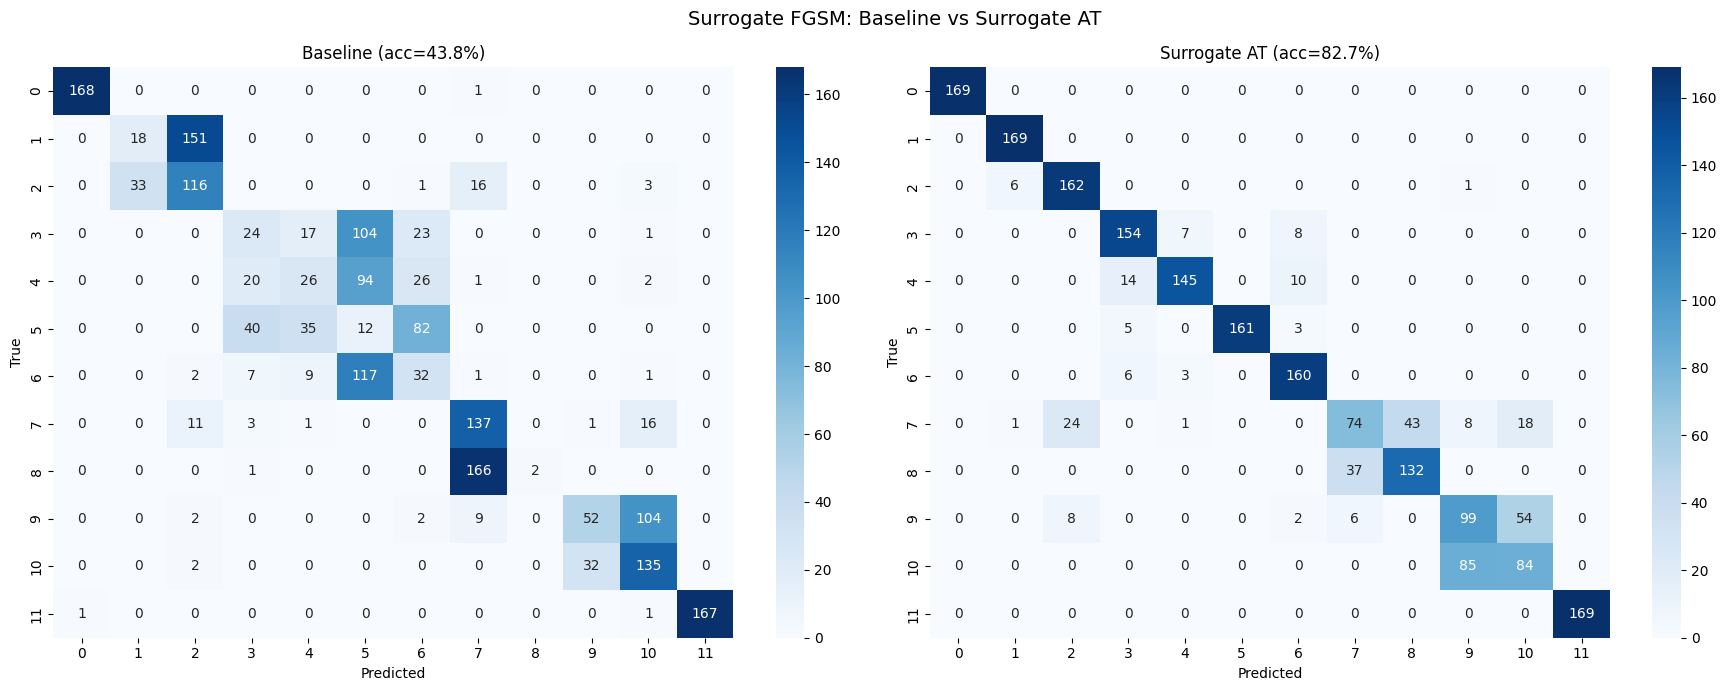

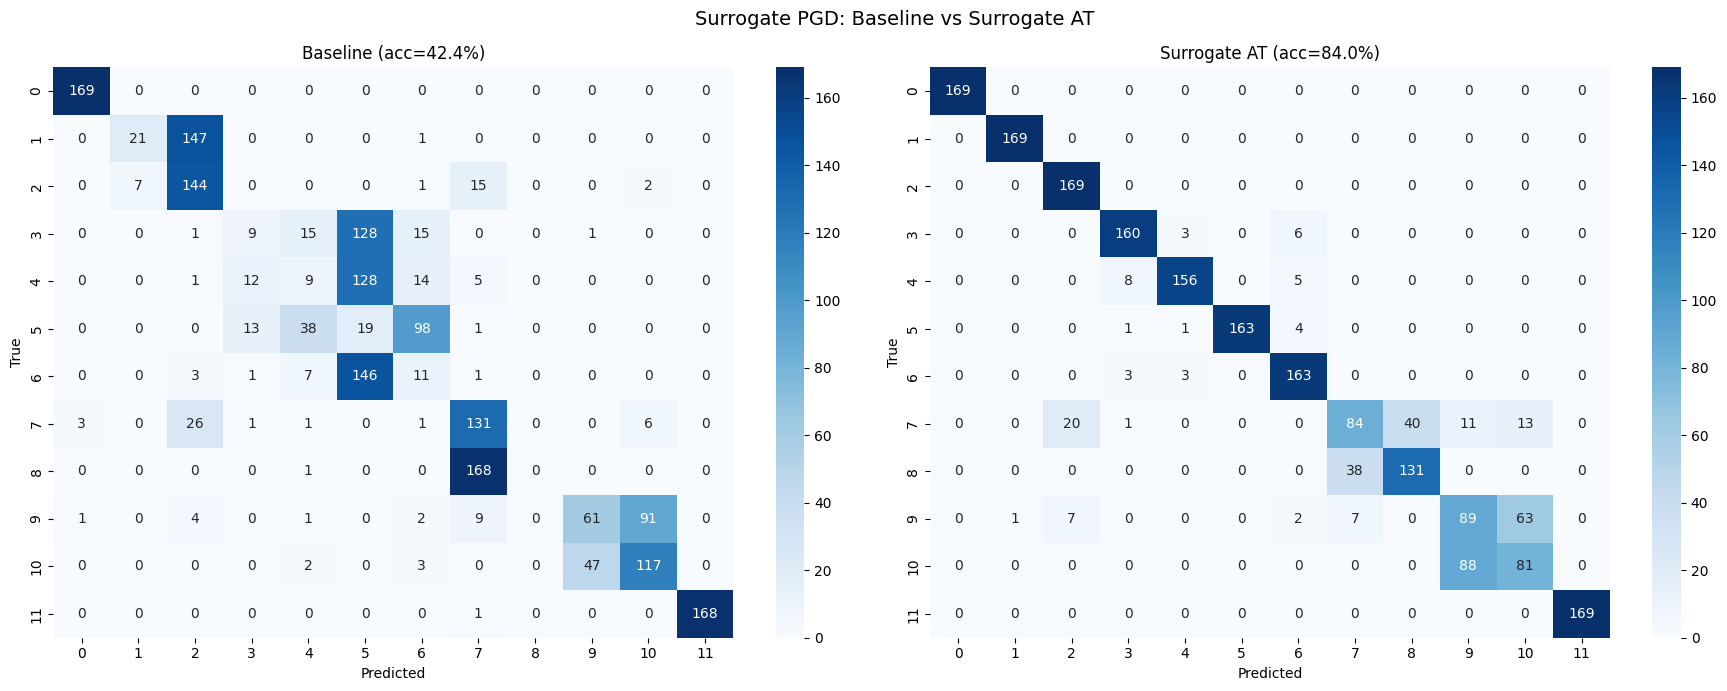

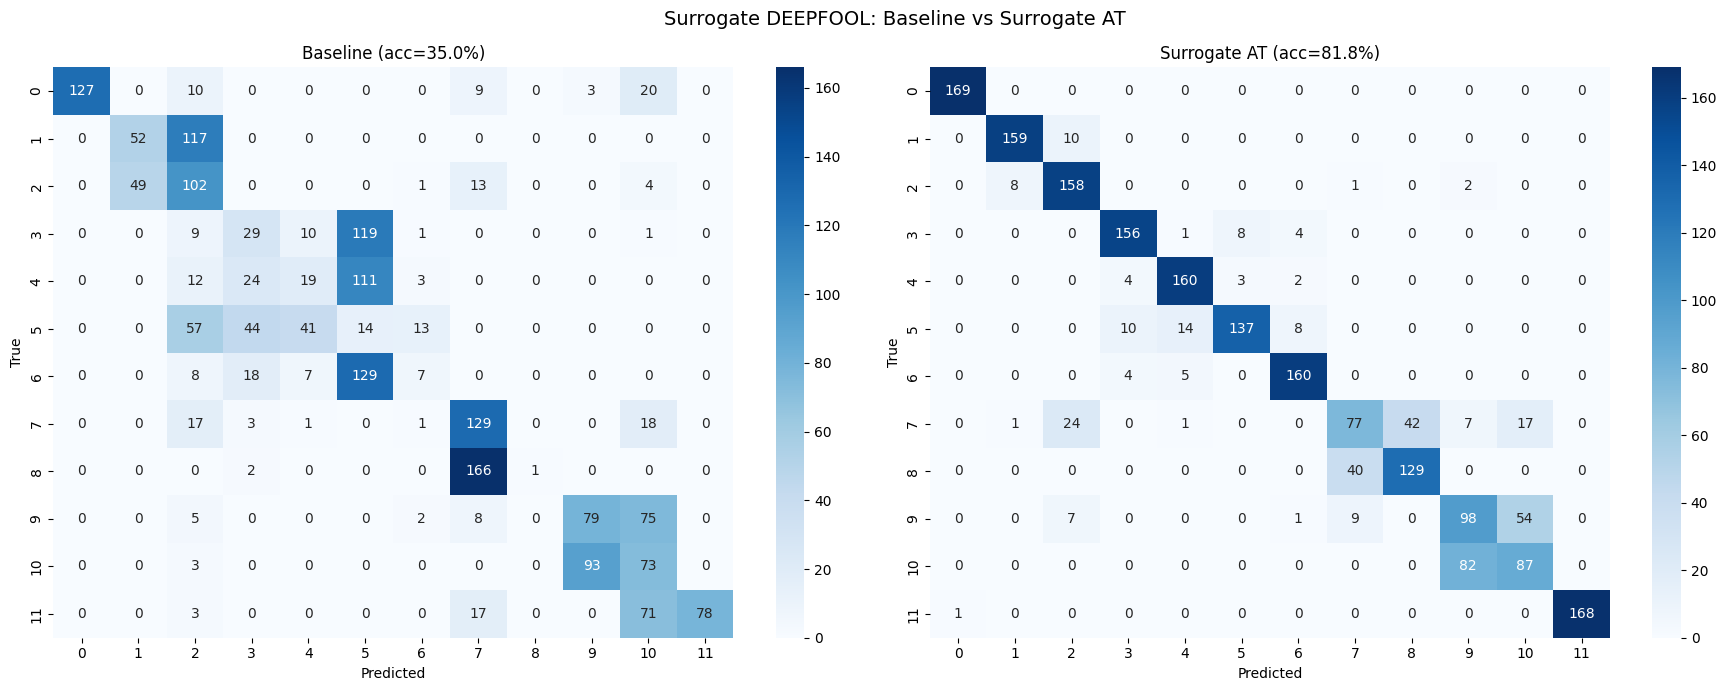

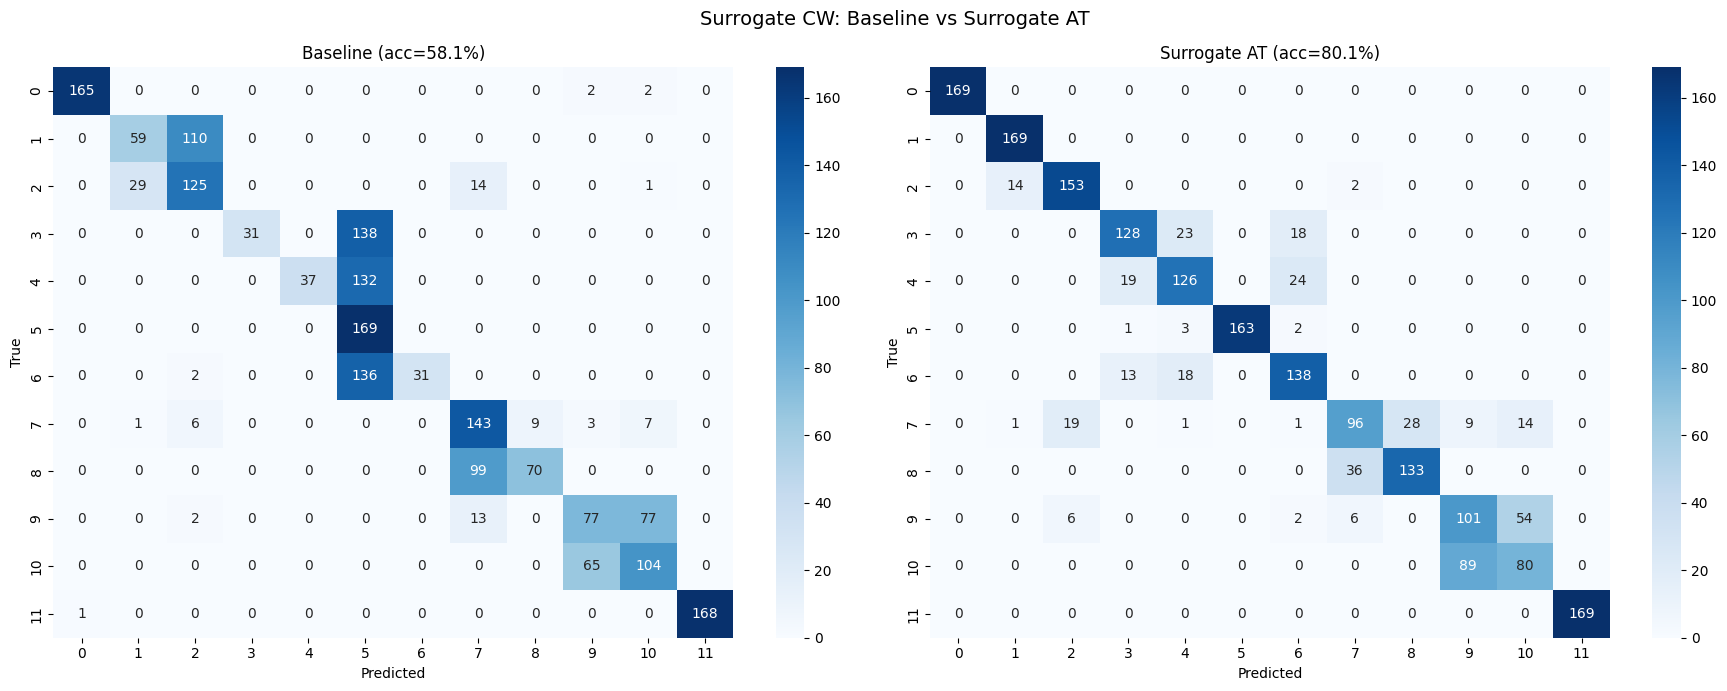

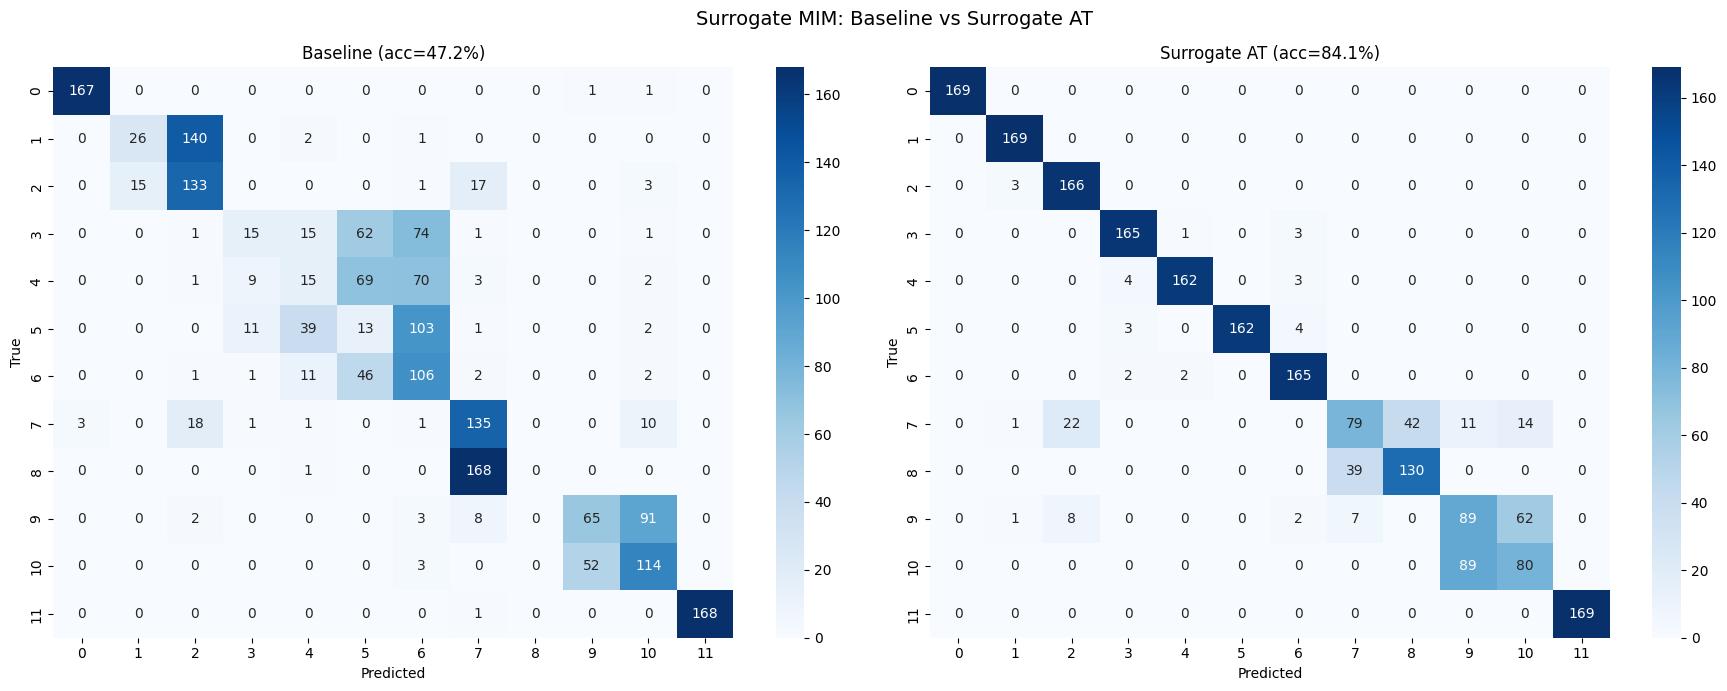

In [67]:
# Confusion matrices: before vs after AT for each attack
for atk in ATTACKS:
    path = os.path.join(SURR_EVAL_DIR, f'surrogate_{atk}_adv.csv')
    if not os.path.exists(path):
        continue
    df_adv = pd.read_csv(path)
    X_adv = df_adv.drop(columns=['Label']).values.astype(np.float32)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Surrogate {atk.upper()}: Baseline vs Surrogate AT', fontsize=14)

    for ax, (name, clf) in zip(axes, [('Baseline', clf_baseline), ('Surrogate AT', clf_surr_at)]):
        pred = np.argmax(clf.predict(X_adv), axis=1)
        cm = confusion_matrix(y_test, pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        acc = accuracy_score(y_test, pred) * 100
        ax.set_title(f'{name} (acc={acc:.1f}%)')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
    plt.tight_layout()
    plt.show()